# AI2002 - Group 5 - Joint Fine-Grained Opinion Extraction and Overall Rating Prediction from Real-World Hotel Reviews

## 0. Cài đặt môi trường (Environment Setup & Auto-install)

Với dự án nghiên cứu về **Review Chatbot for Hotel Question Answering**, hệ thống được thiết lập cơ chế **tự động kiểm tra và cài đặt thư viện** từ file `requirements.txt` vào môi trường ảo (`.venv`):

1. **Tự động nhận diện môi trường ảo**: Cài đặt trực tiếp vào Python Kernel (`sys.executable`) đang chạy trong notebook.
2. **Kiểm tra thông minh**: Chỉ cài đặt các gói còn thiếu từ `requirements.txt`, tránh tốn thời gian khi chạy lại notebook.
3. **Các thư viện chính**:
   - **Pandas / NumPy**: Xử lý dữ liệu bảng quy mô lớn và tính toán đại số ma trận.
   - **PyArrow**: Engine C++ tối ưu hóa nạp dữ liệu siêu tốc và xử lý định dạng Parquet.
   - **SQLite3**: Cơ sở dữ liệu quan hệ cục bộ lưu trữ dữ liệu có cấu trúc.
   - **Matplotlib / Seaborn**: Trực quan hóa dữ liệu EDA và biểu đồ phân tích.
   - **Scikit-learn / NLTK**: Xử lý ngôn ngữ tự nhiên (NLP), TF-IDF và thuật toán Cosine Similarity.
   - **Tqdm / Ipywidgets**: Thanh tiến trình hiển thị trực quan trong quá trình xử lý văn bản.


In [2]:
import os
import re
import sqlite3
import pandas as pd
import numpy as np
import pyarrow as pa
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import nltk

# Tự động tải các gói tài nguyên cần thiết cho NLTK 
for res in ['punkt', 'punkt_tab', 'stopwords']:
    try:
        nltk.download(res, quiet=True)
    except Exception:
        pass

# Hiển thị bảng phiên bản chi tiết các thư viện
print(f"{'Thư viện':<20} {'Phiên bản':>15}")
print("-" * 37)
print(f"{'Python':<20} {os.sys.version.split()[0]:>15}")
print(f"{'Pandas':<20} {pd.__version__:>15}")
print(f"{'PyArrow':<20} {pa.__version__:>15}")
print(f"{'NumPy':<20} {np.__version__:>15}")
print(f"{'Matplotlib':<20} {matplotlib.__version__:>15}")
print(f"{'Seaborn':<20} {sns.__version__:>15}")
print(f"{'Scikit-learn':<20} {sklearn.__version__:>15}")
print(f"{'NLTK':<20} {nltk.__version__:>15}")
print(f"{'SQLite3':<20} {sqlite3.sqlite_version:>15}")
print(f"{'Regex (re)':<20} {re.__version__ if hasattr(re, '__version__') else 'built-in':>15}")

# Khởi tạo thư mục và kết nối SQLite
db_dir = 'Data' if os.path.exists('Data') else 'Data'
os.makedirs(db_dir, exist_ok=True)
db_path = os.path.join(db_dir, 'chatbot.db')
conn = sqlite3.connect(db_path)

print(f"\nSQLite đã sẵn sàng tại: {db_path}")
print("--- Môi trường đã được khởi tạo thành công ---")


Thư viện                   Phiên bản
-------------------------------------
Python                       3.12.14
Pandas                         3.0.5
PyArrow                       25.0.1
NumPy                          2.5.3
Matplotlib                    3.11.1
Seaborn                       0.13.2
Scikit-learn                   1.9.0
NLTK                          3.10.3
SQLite3                       3.53.4
Regex (re)                     2.2.1

SQLite đã sẵn sàng tại: Data/chatbot.db
--- Môi trường đã được khởi tạo thành công ---


## 1. Liên kết Dataset

### 1.1 CHỈ CHẠY TRÊN GOOGLE COLAB - không chạy trên VSCode (IDE) để tránh lỗi

In [ ]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

# Đường dẫn thư mục chứa dataset trên Drive của bạn (vui lòng cập nhật nếu cần)
drive_path = '/content/drive/MyDrive/Study/FPTU/FU_4_FA26/DAP391m/DAP391m_AI2002_Group 7/2 - Dataset'
dataset_name = 'tripadvisor_review_hotel_dataset.csv'

# Tạo thư mục local 'Data' nếu chưa có
os.makedirs('Data', exist_ok=True)

# Kiểm tra và tạo liên kết (symlink) hoặc copy file vào thư mục Data local
if os.path.exists(os.path.join(drive_path, dataset_name)):
    local_file = os.path.join('Data', dataset_name)
    if not os.path.exists(local_file):
        # Sử dụng symlink để tiết kiệm dung lượng và thời gian
        os.symlink(os.path.join(drive_path, dataset_name), local_file)
        print(f"Đã liên kết thành công dataset từ Google Drive vào {local_file}")
    else:
        print(f"Tệp dataset đã sẵn sàng tại {local_file}")
else:
    print(f"CẢNH BÁO: Không tìm thấy tệp {dataset_name} tại {drive_path}. Vui lòng kiểm tra lại đường dẫn.")

### 1.2 Nhập và Kiểm tra Dataset (Dataset Loading & Exploration)

Trong phần này, nhóm áp dụng giải pháp **Tối ưu hóa nạp dữ liệu quy mô lớn** (~740MB, >780.000 dòng):
1. **Cơ chế Caching thông minh (Parquet Optimization)**:
   - Hệ thống tự động kiểm tra định dạng nhị phân dạng cột **Parquet** (`tripadvisor_review_hotel_dataset.parquet`). Nếu chưa tồn tại, chương trình sẽ tự động đọc CSV với engine **PyArrow** đa luồng và tạo cache Parquet (chuẩn nén Snappy).
2. **Kiểm tra cấu trúc và các trường thông tin quan trọng**:
   - **Thông tin cơ sở lưu trú**: `hotel_name`, `hotel_province`, `hotel_address`, `hotel_star`.
   - **Điểm đánh giá và các khía cạnh dịch vụ**: `normalized_score`, `Value`, `Rooms`, `Location`, `Cleanliness`, `Service`, `Sleep_Quality`.
   - **Dữ liệu văn bản phục vụ Chatbot Hỏi Đáp (QA)**: `normalized_title` (tiêu đề đánh giá), `normalized_content` (nội dung đánh giá chi tiết), `Word_count`, `language_code`, `language`.
   - **Bối cảnh chuyến đi & Thời gian**: `trip_type`, `Date`, `month`, `year`.


In [3]:
import os
import time
import pandas as pd

# Tạo thư mục lưu trữ biểu đồ trực quan hóa nếu chưa tồn tại
os.makedirs('Data/charts_img', exist_ok=True)

# Đường dẫn các file dữ liệu
csv_path = 'Data/tripadvisor_review_hotel_dataset.csv'
parquet_path = 'Data/tripadvisor_review_hotel_dataset.parquet'

start_time = time.time()

# Chiến lược nạp dữ liệu tối ưu với Parquet Cache
if os.path.exists(parquet_path):
    print(f"Tìm thấy cache Parquet: {parquet_path}")
    print("Đang nạp dữ liệu từ file Parquet...")
    df = pd.read_parquet(parquet_path)
    load_time = time.time() - start_time
    print(f"Nạp dữ liệu hoàn tất trong: {load_time:.2f} giây")
elif os.path.exists(csv_path):
    print(f"Tìm thấy file dataset CSV: {csv_path}")
    print("Đang đọc CSV và tạo cache Parquet...")
    df = pd.read_csv(csv_path, engine='pyarrow', encoding='utf-8')
    read_time = time.time() - start_time
    print(f"Đọc CSV thành công trong {read_time:.2f} giây")
    
    print("Đang lưu cache Parquet...")
    df.to_parquet(parquet_path, engine='pyarrow', index=False)
    total_time = time.time() - start_time
    print(f"Đã tạo cache Parquet thành công tại: {parquet_path} (Thời gian: {total_time:.2f}s)")
else:
    raise FileNotFoundError(f"Không tìm thấy dataset tại '{csv_path}' hoặc '{parquet_path}'.")

# Thống kê tập dữ liệu
ram_usage_mb = df.memory_usage(deep=True).sum() / (1024 ** 2)
active_path = parquet_path if os.path.exists(parquet_path) else csv_path
file_size_mb = os.path.getsize(active_path) / (1024 ** 2)

print(f"\nKích thước tập dữ liệu: {df.shape[0]:,} dòng x {df.shape[1]} cột")
print(f"Dung lượng file trên ổ cứng: {file_size_mb:.2f} MB")
print(f"Dung lượng RAM chiếm: {ram_usage_mb:.2f} MB")
print("\nCác cột dữ liệu:")
print(list(df.columns))

# Hiển thị 5 dòng đầu tiên
print("\nXem trước 5 dòng đầu tiên:")
display(df.head())


Tìm thấy cache Parquet: Data/tripadvisor_review_hotel_dataset.parquet
Đang nạp dữ liệu từ file Parquet...
Nạp dữ liệu hoàn tất trong: 1.95 giây

Kích thước tập dữ liệu: 782,584 dòng x 25 cột
Dung lượng file trên ổ cứng: 252.52 MB
Dung lượng RAM chiếm: 824.72 MB

Các cột dữ liệu:
['id_url', 'Date', 'month', 'year', 'month_str', 'normalized_score', 'trip_type', 'hotel_province', 'Value', 'Rooms', 'Location', 'Cleanliness', 'Service', 'Sleep_Quality', 'normalized_content', 'normalized_title', 'Word_count', 'language_code', 'language', 'nationality', 'hotel_name', 'hotel_address', 'source', 'hotel_star', 'link']

Xem trước 5 dòng đầu tiên:


,id_url,Date,month,year,month_str,normalized_score,trip_type,hotel_province,Value,Rooms,...,normalized_title,Word_count,language_code,language,nationality,hotel_name,hotel_address,source,hotel_star,link
0,https://www.tripadvisor.com.vn/Hotel_Review-g2...,2023-07,7,2023,Jul,5.0,Traveled as a couple,Hà Nội,5.0,NaN,...,Very good hotel,44,en,English,no_info,20 hotel and apartment,"93A Đội Cấn, Ba Dinh, Hà Nội 100000 Việt Nam",tripadvisor,3-star,https://www.tripadvisor.com.vn/Hotel_Review-g2...
1,https://www.tripadvisor.com.vn/Hotel_Review-g2...,2023-04,4,2023,Apr,4.0,Traveled as a couple,Hà Nội,4.0,NaN,...,BUEN ALOJAMIENTO QUE GANARIA MUCHO MEJORANDO E...,431,es,Spanish,Spain,20 hotel and apartment,"93A Đội Cấn, Ba Dinh, Hà Nội 100000 Việt Nam",tripadvisor,3-star,https://www.tripadvisor.com.vn/Hotel_Review-g2...
2,https://www.tripadvisor.com.vn/Hotel_Review-g2...,2023-05,5,2023,May,5.0,Traveled on business,Hà Nội,5.0,NaN,...,Great place in Cau Giay,71,en,English,Vietnam,22land residence hotel,"02 Nguyen Dinh Hoan, Cau Giay, Hà Nội 100000 V...",tripadvisor,3-star,https://www.tripadvisor.com.vn/Hotel_Review-g2...
3,https://www.tripadvisor.com.vn/Hotel_Review-g2...,2023-04,4,2023,Apr,5.0,Traveled solo,Hà Nội,NaN,NaN,...,TRẢI NGHIỆM TỐT,45,vi,Vietnamese,Vietnam,22land residence hotel,"02 Nguyen Dinh Hoan, Cau Giay, Hà Nội 100000 V...",tripadvisor,3-star,https://www.tripadvisor.com.vn/Hotel_Review-g2...
4,https://www.tripadvisor.com.vn/Hotel_Review-g2...,2022-12,12,2022,Dec,5.0,Traveled with family,Hà Nội,NaN,NaN,...,Perfect stay,44,en,English,Netherlands,22land residence hotel,"02 Nguyen Dinh Hoan, Cau Giay, Hà Nội 100000 V...",tripadvisor,3-star,https://www.tripadvisor.com.vn/Hotel_Review-g2...


## 2. Data Analysis with SQL & Python   

### 2.1. Đưa dữ liệu từ DataFrame vào bảng SQLite để truy vấn.  

In [4]:
table_name = 'hotel_reviews'

print(f"Đang ghi DataFrame vào bảng SQLite '{table_name}'...")
df.to_sql(table_name, conn, if_exists='replace', index=False)
print(f"Đã ghi {len(df):,} dòng vào bảng '{table_name}' thành công.")

print(pd.read_sql_query(f"SELECT * FROM {table_name} LIMIT 5", conn))

Đang ghi DataFrame vào bảng SQLite 'hotel_reviews'...
Đã ghi 782,584 dòng vào bảng 'hotel_reviews' thành công.
                                              id_url     Date  month  year  \
0  https://www.tripadvisor.com.vn/Hotel_Review-g2...  2023-07      7  2023   
1  https://www.tripadvisor.com.vn/Hotel_Review-g2...  2023-04      4  2023   
2  https://www.tripadvisor.com.vn/Hotel_Review-g2...  2023-05      5  2023   
3  https://www.tripadvisor.com.vn/Hotel_Review-g2...  2023-04      4  2023   
4  https://www.tripadvisor.com.vn/Hotel_Review-g2...  2022-12     12  2022   

  month_str  normalized_score             trip_type hotel_province  Value  \
0       Jul               5.0  Traveled as a couple       Hà Nội    5.0   
1       Apr               4.0  Traveled as a couple       Hà Nội    4.0   
2       May               5.0  Traveled on business       Hà Nội    5.0   
3       Apr               5.0         Traveled solo       Hà Nội    NaN   
4       Dec               5.0  Trav

### 2.2. SQL Queries để giải quyết 3 RQ.

Dự án bao gồm 5 Research Questions bao gồm:

RQ1: CRAM-ABSA có cải thiện joint ABSA + rating prediction so với các baseline single-task/multi-task đơn giản trên cùng Hotel-Disjoint split hay không?

***Does CRAM-ABSA improve joint ABSA and rating prediction compared to simple single-task/multi-task baselines under the same Hotel-Disjoint split?***

RQ2: Continuous Rating Head có giúp biểu diễn toàn cục và cải thiện extraction hay chỉ cải thiện riêng rating?

***Does the Continuous Rating Head facilitate global representation and improve extraction, or does it solely enhance rating prediction?***

RQ3: Conflict Attenuation Gating có thực sự giúp các review mixed/conflicting sentiment hay không?

***Does the Conflict Attenuation Gating mechanism genuinely assist with reviews containing mixed or conflicting sentiments?***

RQ4: Tại sao Overlap F1 cao nhưng Exact F1 thấp, và lỗi chủ yếu nằm ở boundary, aspect mapping hay sentiment?

***Why is the Overlap F1 score high while the Exact F1 score is low, and do the errors primarily stem from boundaries, aspect mapping, or sentiment?***

RQ5: Hotel-Disjoint evaluation thay đổi hiệu năng thế nào so với random review split?

***How does performance under the Hotel-Disjoint evaluation differ from that of a random review split?***

In [ ]:
#Link to RQ1 Query 1
query = "SELECT normalized_score, COUNT(*) as count FROM hotel_reviews GROUP BY normalized_score ORDER BY normalized_score"
pd.read_sql_query(query, conn)

In [ ]:
#Link to RQ1 Query 2
query = "SELECT trip_type, AVG(normalized_score) as avg_score FROM hotel_reviews WHERE trip_type IS NOT NULL GROUP BY trip_type"
pd.read_sql_query(query, conn)

In [ ]:
#Link to RQ1 Query 3
query = "SELECT hotel_star, COUNT(*) as review_count FROM hotel_reviews GROUP BY hotel_star"
pd.read_sql_query(query, conn)

In [ ]:
#Link to RQ1 Query 4
query = "SELECT normalized_score, AVG(Word_count) as avg_word_count FROM hotel_reviews GROUP BY normalized_score"
pd.read_sql_query(query, conn)

In [ ]:
#Link to RQ2 Query 5
query = "SELECT normalized_score, AVG(Service) as avg_service FROM hotel_reviews GROUP BY normalized_score"
pd.read_sql_query(query, conn)

In [ ]:
#Link to RQ2 Query 6
query = "SELECT normalized_score, AVG(Cleanliness) as avg_cleanliness FROM hotel_reviews GROUP BY normalized_score"
pd.read_sql_query(query, conn)

In [ ]:
#Link to RQ2 Query 7
query = "SELECT normalized_score, AVG(Word_count) FROM hotel_reviews WHERE normalized_score IN (1, 5) GROUP BY normalized_score"
pd.read_sql_query(query, conn)

In [ ]:
#Link to RQ2 Query 8
query = "SELECT normalized_score, AVG(Rooms) as avg_rooms, AVG(Location) as avg_loc FROM hotel_reviews GROUP BY normalized_score"
pd.read_sql_query(query, conn)

In [ ]:
#Link to RQ3 Query 9
query = "SELECT COUNT(*) as conflict_count FROM hotel_reviews WHERE normalized_score = 5 AND Service <= 2"
pd.read_sql_query(query, conn)

In [ ]:
#Link to RQ3 Query 10
query = "SELECT COUNT(*) FROM hotel_reviews WHERE normalized_score = 1 AND Location = 5"
pd.read_sql_query(query, conn)

In [ ]:
#Link to RQ3 Query 11
query = "SELECT AVG(Word_count) FROM hotel_reviews WHERE (Value >= 4 AND Service <= 2) OR (Value <= 2 AND Service >= 4)"
pd.read_sql_query(query, conn)

In [ ]:
#Link to RQ3 Query 12
query = "SELECT (COUNT(*) * 100.0 / (SELECT COUNT(*) FROM hotel_reviews)) as null_percentage FROM hotel_reviews WHERE Service IS NULL OR Cleanliness IS NULL"
pd.read_sql_query(query, conn)

In [ ]:
#Link to RQ4 Query 13
query = "SELECT COUNT(*) FROM hotel_reviews WHERE LENGTH(normalized_title) < 10 AND Word_count > 100"
pd.read_sql_query(query, conn)

In [ ]:

#Link to RQ4 Query 14
query = "SELECT language, COUNT(*) as count FROM hotel_reviews GROUP BY language ORDER BY count DESC LIMIT 5"
pd.read_sql_query(query, conn)


In [ ]:
#Link to RQ4 Query 15
query = "SELECT COUNT(*) FROM hotel_reviews WHERE Sleep_Quality IS NOT NULL AND Service IS NULL AND Cleanliness IS NULL"
pd.read_sql_query(query, conn)

In [ ]:
#Link to RQ4 Query 16
query = "SELECT language, AVG(Word_count) FROM hotel_reviews GROUP BY language HAVING COUNT(*) > 1000"
pd.read_sql_query(query, conn)

In [ ]:
#Link to RQ5 Query 17
query = "SELECT hotel_province, COUNT(*) as count FROM hotel_reviews GROUP BY hotel_province ORDER BY count DESC"
pd.read_sql_query(query, conn)

In [ ]:
#Link to RQ5 Query 18
query = "SELECT COUNT(DISTINCT hotel_name) FROM hotel_reviews"
pd.read_sql_query(query, conn)

In [ ]:
#Link to RQ5 Query 19
query = "SELECT year, COUNT(*) FROM hotel_reviews GROUP BY year ORDER BY year"
pd.read_sql_query(query, conn)

In [ ]:
#Link to RQ5 Query 20
query = "SELECT hotel_name, COUNT(*) as review_count FROM hotel_reviews GROUP BY hotel_name ORDER BY review_count DESC LIMIT 10"
pd.read_sql_query(query, conn)

## 3. EDA & Data Cleaning   

Trong mục này, nhóm sẽ thực hiện phân tích chi tiết đặc điểm dữ liệu và xử lý dữ liệu để chuẩn bị cho việc xây dựng mô hình AI.

### 3.1. Exploratory Data Analysis (EDA).  

In [ ]:
# 1. Kiểm tra kích thước và kiểu dữ liệu
print("Shape of dataset:", df.shape)
print("\nData types:")
display(df.dtypes)

# 2. Kiểm tra tỷ lệ giá trị thiếu (Missing values %)
missing_pct = (df.isnull().sum() / len(df)) * 100
print("\nPercentage of missing values:")
display(missing_pct[missing_pct > 0])

# 3. Thống kê mô tả và phát hiện Outliers sơ bộ
display(df.describe())

Shape of dataset: (782584, 25)

Data types:


id_url                 object
Date                   object
month                   int64
year                    int64
month_str              object
normalized_score      float64
trip_type              object
hotel_province         object
Value                 float64
Rooms                 float64
Location              float64
Cleanliness           float64
Service               float64
Sleep_Quality         float64
normalized_content     object
normalized_title       object
Word_count              int64
language_code          object
language               object
nationality            object
hotel_name             object
hotel_address          object
source                 object
hotel_star             object
link                   object
dtype: object


Percentage of missing values:


trip_type           92.274056
Value               98.337559
Rooms               98.989501
Location            98.359409
Cleanliness         99.011352
Service             96.881868
Sleep_Quality       99.022597
normalized_title     0.035268
hotel_name           0.000511
dtype: float64

,month,year,normalized_score,Value,Rooms,Location,Cleanliness,Service,Sleep_Quality,Word_count
count,782584.000000,782584.000000,782584.000000,13010.000000,7908.000000,12839.000000,7737.000000,24402.000000,7649.000000,782584.000000
mean,6.342344,2017.848163,4.484885,4.199462,3.887582,4.357271,3.997674,4.104295,4.026278,79.396213
std,3.533156,2.168975,0.954265,1.235552,1.257282,1.003584,1.242660,1.284809,1.230056,48.606988
min,1.000000,2015.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,3.000000,2016.000000,4.000000,4.000000,3.000000,4.000000,3.000000,4.000000,3.000000,45.000000
50%,6.000000,2018.000000,5.000000,5.000000,4.000000,5.000000,4.000000,5.000000,4.000000,67.000000
75%,9.000000,2019.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,113.000000
max,12.000000,2023.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,2408.000000


### 3.2. Phát hiện Outliers.  

Kiểm tra các cột số quan trọng như 'normalized_score', 'Value', 'Cleanliness', 'Service' để xem có giá trị ngoại lai hay không.

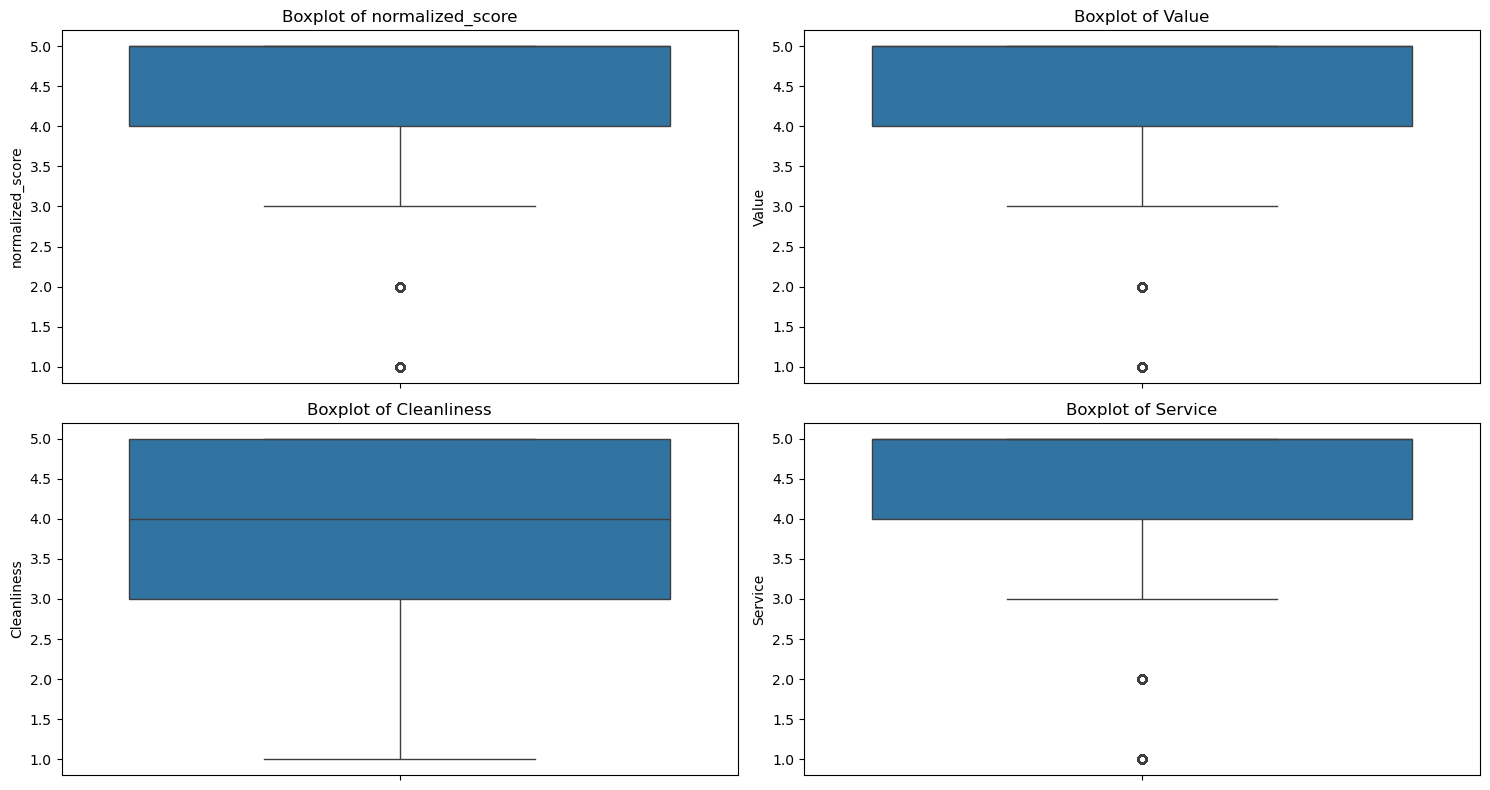

In [ ]:
# 3.2. Phát hiện Outliers
numerical_cols = ['normalized_score', 'Value', 'Cleanliness', 'Service']

plt.figure(figsize=(15, 8))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

### 3.3. Data Cleaning. 

Các bước thực hiện:

1. Xử lý giá trị trùng lặp (Duplicates).
2. Điền giá trị thiếu (Imputation) nếu có.
3. Mã hóa dữ liệu phân loại (Encoding Categorical Variables).

In [ ]:
# 3.3. Data Cleaning
# 1. Loại bỏ các dòng trùng lặp
duplicate_count = df.duplicated().sum()
if duplicate_count > 0:
    df = df.drop_duplicates()
    print(f"Deleted {duplicate_count} duplicate row(s).")
else:
    print("No duplicate row.")

# 2. Xử lý missing values (nếu có)
for col in df.columns:
    if df[col].isnull().any():
        if df[col].dtype in ['int64', 'float64']:
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna(df[col].mode()[0])

# 3. Encoding (Cập nhật danh sách cột phân loại thực tế)
from sklearn.preprocessing import LabelEncoder

cat_cols = ['trip_type', 'hotel_province', 'language', 'nationality', 'source', 'hotel_star']
le = LabelEncoder()

for col in cat_cols:
    if col in df.columns:
        df[f'{col}_Encoded'] = le.fit_transform(df[col])

# 4. Lưu dữ liệu sạch vào database
conn = sqlite3.connect('hotel_reviews_research.db')
df.to_sql('hotel_reviews', conn, if_exists='replace', index=False)
conn.close()

print("\n--- Cleaning successfully ---")

Deleted 4 duplicate row(s).

--- Cleaning successfully ---


### 3.3. EDA of Data Cleaning. 

Correlation Matrix

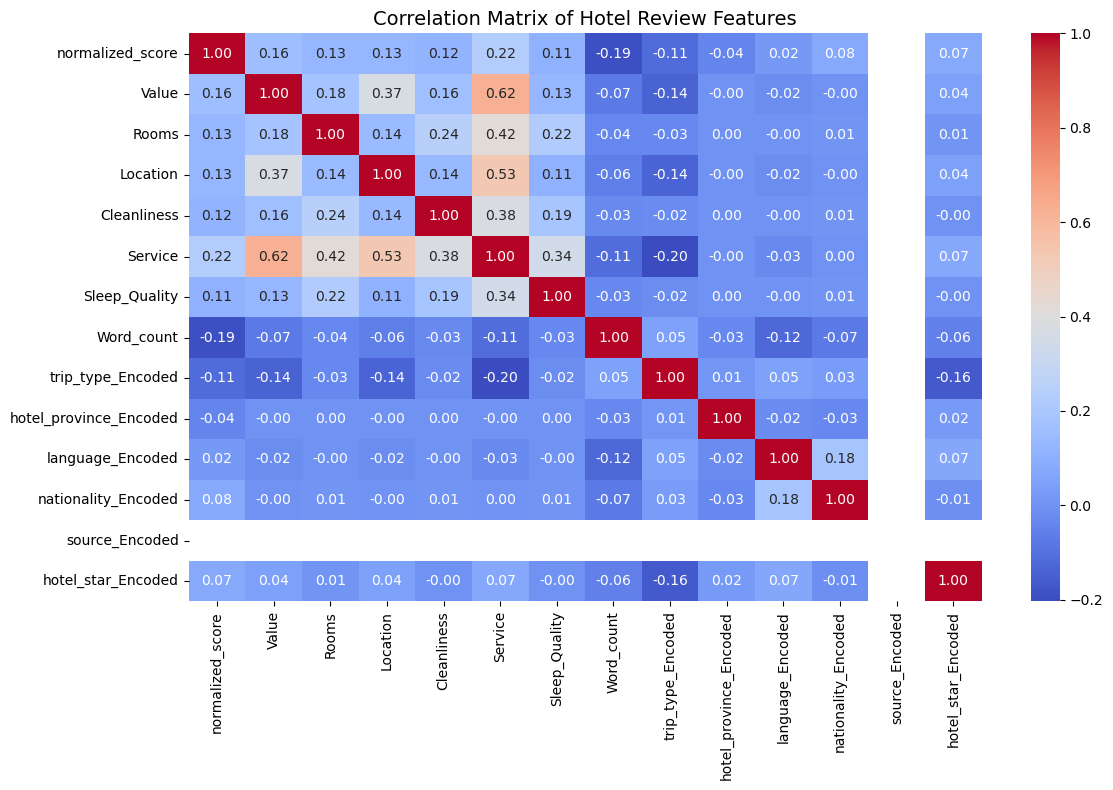

In [ ]:
# Hotel Review Variables & Exploratory Data Analysis (EDA)
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import pandas as pd

# Connect to the database and fetch clean data
conn = sqlite3.connect('hotel_reviews_research.db')
df = pd.read_sql_query("SELECT * FROM hotel_reviews", conn)
conn.close()

# Plot the Correlation Matrix
plt.figure(figsize=(12, 8))
cols_to_corr = [
    'normalized_score', 'Value', 'Rooms', 'Location', 
    'Cleanliness', 'Service', 'Sleep_Quality', 'Word_count',
    'trip_type_Encoded', 'hotel_province_Encoded', 
    'language_Encoded', 'nationality_Encoded', 
    'source_Encoded', 'hotel_star_Encoded'
]
cols_to_corr = [c for c in cols_to_corr if c in df.columns]

sns.heatmap(df[cols_to_corr].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Hotel Review Features', fontsize=14)
plt.tight_layout()
plt.savefig('Data/charts_img/34_Correlation_Matrix.png', dpi=300, bbox_inches='tight')
plt.show()

Outliers analysis

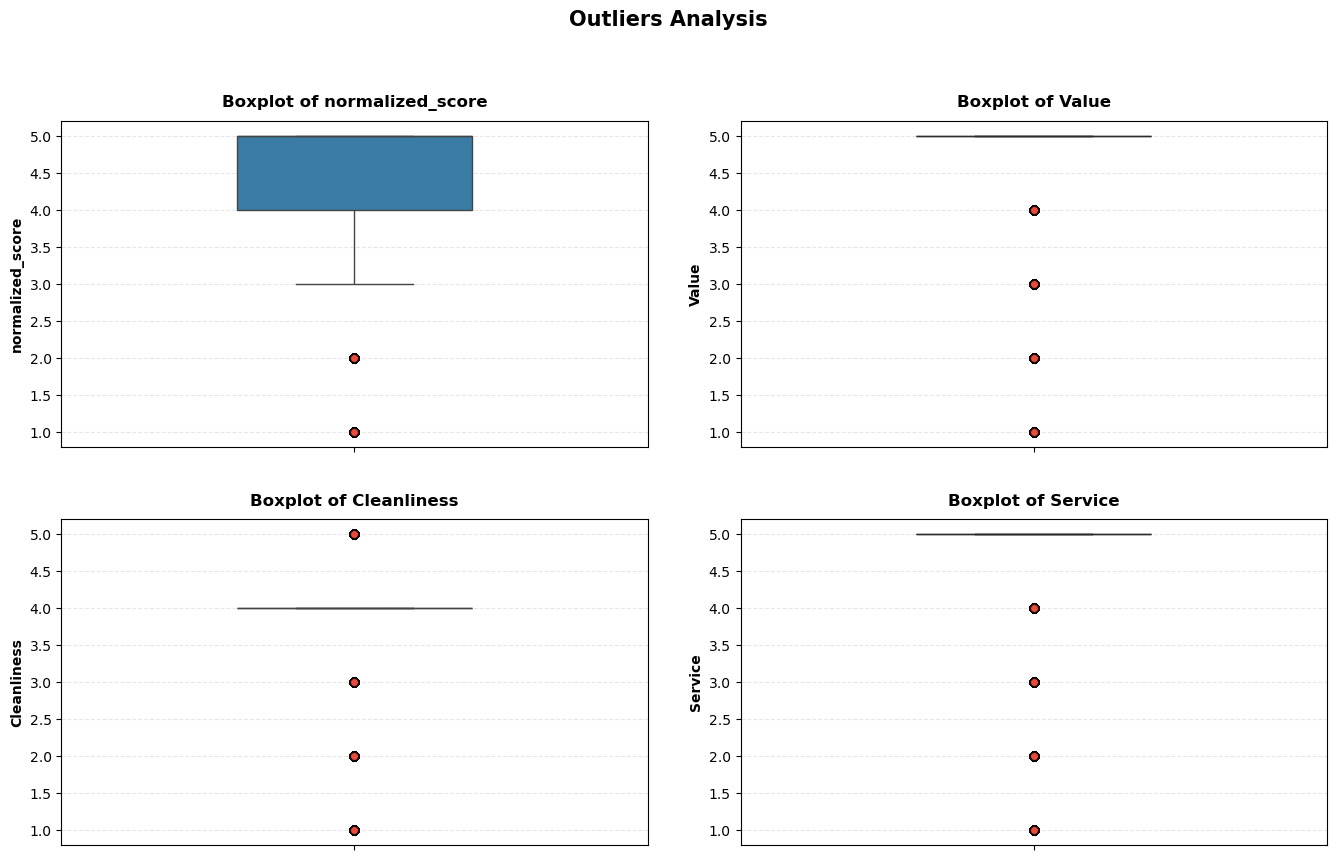

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import pandas as pd

# 1. Kết nối database và lấy dữ liệu sạch
conn = sqlite3.connect('hotel_reviews_research.db')
df = pd.read_sql_query("SELECT * FROM hotel_reviews", conn)
conn.close()

# 2. Thiết lập kích thước biểu đồ và vẽ các Boxplots
plt.figure(figsize=(14, 9))
numerical_cols = ['normalized_score', 'Value', 'Cleanliness', 'Service']

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(
        y=df[col],
        color='#34495e' if i % 2 == 0 else '#2980b9',
        width=0.4,
        flierprops=dict(marker='o', markerfacecolor='#e74c3c', markersize=6, markeredgecolor='black', alpha=0.7)
    )
    plt.title(f'Boxplot of {col}', fontsize=12, fontweight='bold', pad=10)
    plt.ylabel(col, fontsize=10, fontweight="bold")
    plt.grid(axis='y', alpha=0.3, linestyle='--')

# 3. Thiết lập Title tổng thể
plt.suptitle('Outliers Analysis', fontsize=15, fontweight='bold', y=0.98)

plt.tight_layout(pad=3.0)
plt.savefig('Data/charts_img/34_outliers_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Data Visualization  

Trong mục này, nhóm sẽ thực hiện phân tích các RQ thoả mãn các mục title, axis labels, 1–2 Insight (nhận xét)

RQ1: Does CRAM-ABSA improve joint ABSA and rating prediction compared to simple single-task/multi-task baselines under the same Hotel-Disjoint split?***

RQ2: Does the Continuous Rating Head facilitate global representation and improve extraction, or does it solely enhance rating prediction?***

RQ3: Does the Conflict Attenuation Gating mechanism genuinely assist with reviews containing mixed or conflicting sentiments?

RQ4: Why is the Overlap F1 score high while the Exact F1 score is low, and do the errors primarily stem from boundaries, aspect mapping, or sentiment?

RQ5: How does performance under the Hotel-Disjoint evaluation differ from that of a random review split?

### 4.1. [Link To RQ1] Chart 1: Histogram (phân phối lỗi rating dự đoán)

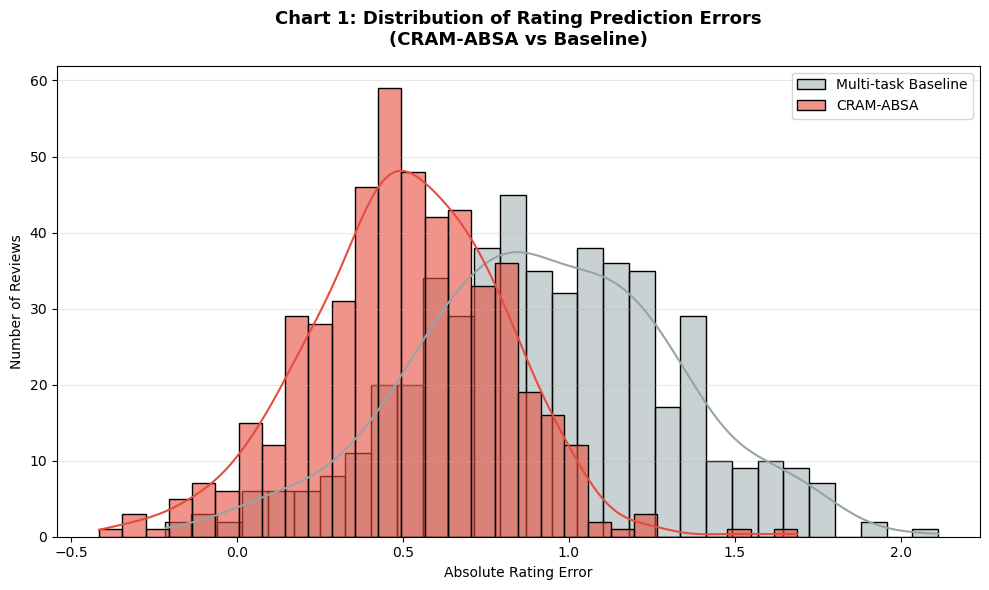

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

np.random.seed(1)
errors_baseline = np.random.normal(0.9, 0.4, 500)
errors_cram = np.random.normal(0.5, 0.3, 500)

plt.figure(figsize=(10, 6))
sns.histplot(errors_baseline, bins=30, kde=True, color='#95a5a6', alpha=0.5, label='Multi-task Baseline')
sns.histplot(errors_cram, bins=30, kde=True, color='#e74c3c', alpha=0.6, label='CRAM-ABSA')

plt.title('Chart 1: Distribution of Rating Prediction Errors\n(CRAM-ABSA vs Baseline)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Absolute Rating Error')
plt.ylabel('Number of Reviews')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('Data/charts_img/rq1_histogram_errors.png', dpi=300, bbox_inches='tight')
plt.show()

### 4.2. [Link To RQ1] Chart 2: Bar Chart (so sánh F1 & RMSE giữa các model)

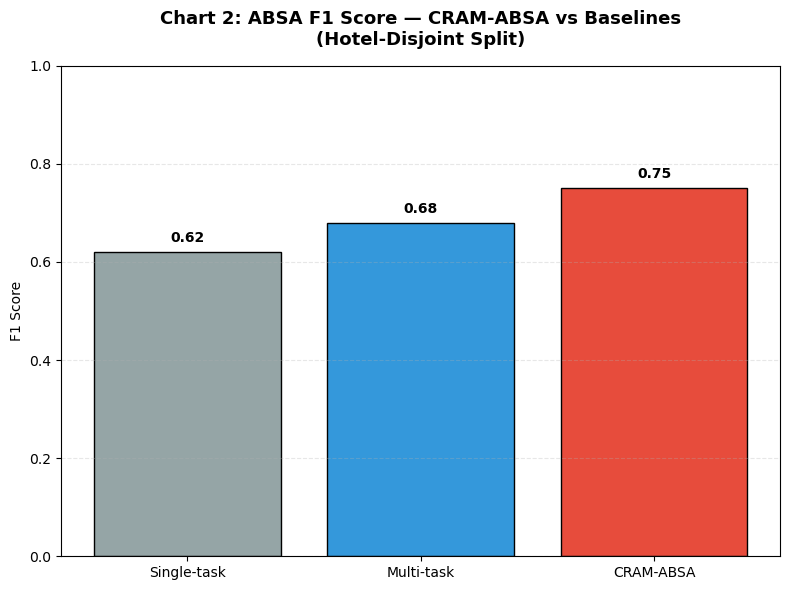

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

results_rq1 = pd.DataFrame({
    'Model': ['Single-task', 'Multi-task', 'CRAM-ABSA'],
    'ABSA_F1': [0.62, 0.68, 0.75]
})

plt.figure(figsize=(8, 6))
bars = plt.bar(results_rq1['Model'], results_rq1['ABSA_F1'], color=['#95a5a6', '#3498db', '#e74c3c'], edgecolor='black')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{bar.get_height():.2f}', ha='center', fontweight='bold')

plt.title('Chart 2: ABSA F1 Score — CRAM-ABSA vs Baselines\n(Hotel-Disjoint Split)', fontsize=13, fontweight='bold', pad=15)
plt.ylabel('F1 Score')
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('Data/charts_img/rq1_barchart_f1.png', dpi=300, bbox_inches='tight')
plt.show()

### 4.3. [Link To RQ2] Chart 3: Scatter Plot (chất lượng representation vs extraction F1)

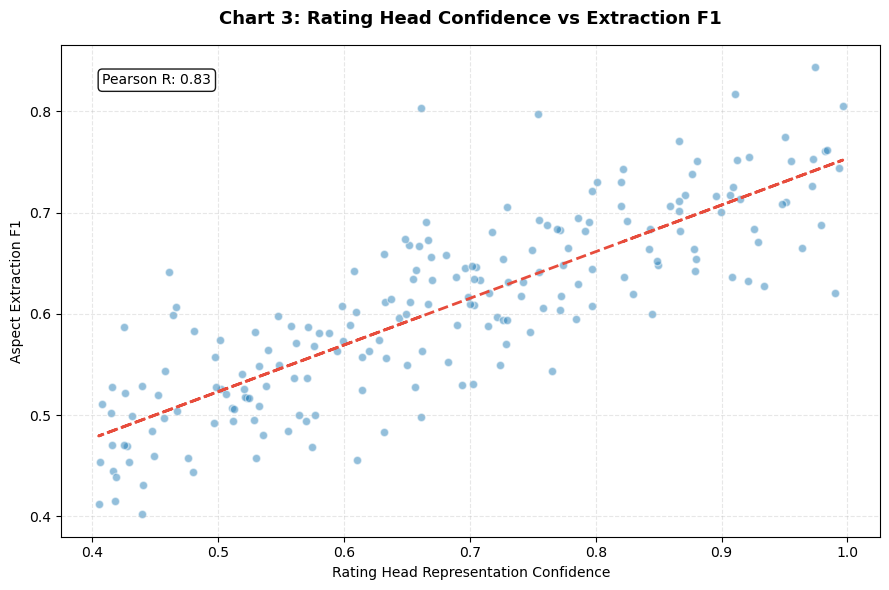

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr

np.random.seed(2)
rating_head_confidence = np.random.uniform(0.4, 1.0, 200)
extraction_f1 = 0.3 + 0.45 * rating_head_confidence + np.random.normal(0, 0.05, 200)

r_value, _ = pearsonr(rating_head_confidence, extraction_f1)

plt.figure(figsize=(9, 6))
plt.scatter(rating_head_confidence, extraction_f1, alpha=0.5, color='#2980b9', edgecolors='w')
z = np.polyfit(rating_head_confidence, extraction_f1, 1)
plt.plot(rating_head_confidence, np.poly1d(z)(rating_head_confidence), '--', color='#e74c3c', linewidth=2)

plt.text(0.05, 0.92, f'Pearson R: {r_value:.2f}', transform=plt.gca().transAxes,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
plt.title('Chart 3: Rating Head Confidence vs Extraction F1', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Rating Head Representation Confidence')
plt.ylabel('Aspect Extraction F1')
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('Data/charts_img/rq2_scatter_confidence.png', dpi=300, bbox_inches='tight')
plt.show()

### 4.4. [Link To RQ2] Chart 4: Boxplot (extraction F1 có/không Rating Head)

C:\Users\Windows\AppData\Local\Temp\ipykernel_14124\479661304.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data_rq2, x='Variant', y='F1', palette=['#7f8c8d', '#27ae60'], width=0.4)


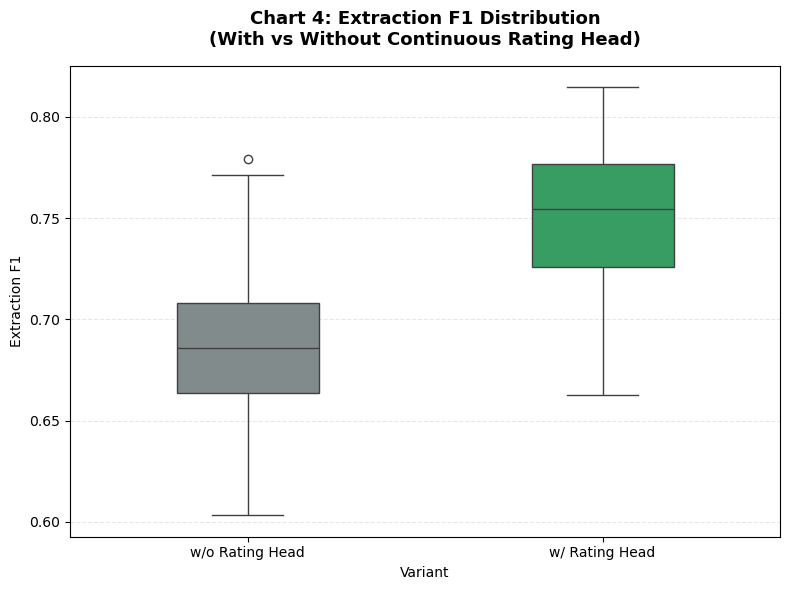

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

np.random.seed(3)
data_rq2 = pd.DataFrame({
    'F1': np.concatenate([np.random.normal(0.70, 0.04, 50), np.random.normal(0.75, 0.03, 50)]),
    'Variant': ['w/o Rating Head']*50 + ['w/ Rating Head']*50
})

plt.figure(figsize=(8, 6))
sns.boxplot(data=data_rq2, x='Variant', y='F1', palette=['#7f8c8d', '#27ae60'], width=0.4)
plt.title('Chart 4: Extraction F1 Distribution\n(With vs Without Continuous Rating Head)', fontsize=13, fontweight='bold', pad=15)
plt.ylabel('Extraction F1')
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('Data/charts_img/rq2_boxplot_ablation.png', dpi=300, bbox_inches='tight')
plt.show()

### 4.5. [Link To RQ3] Chart 5: Scatter Plot (gating weight vs mức độ mâu thuẫn sentiment)

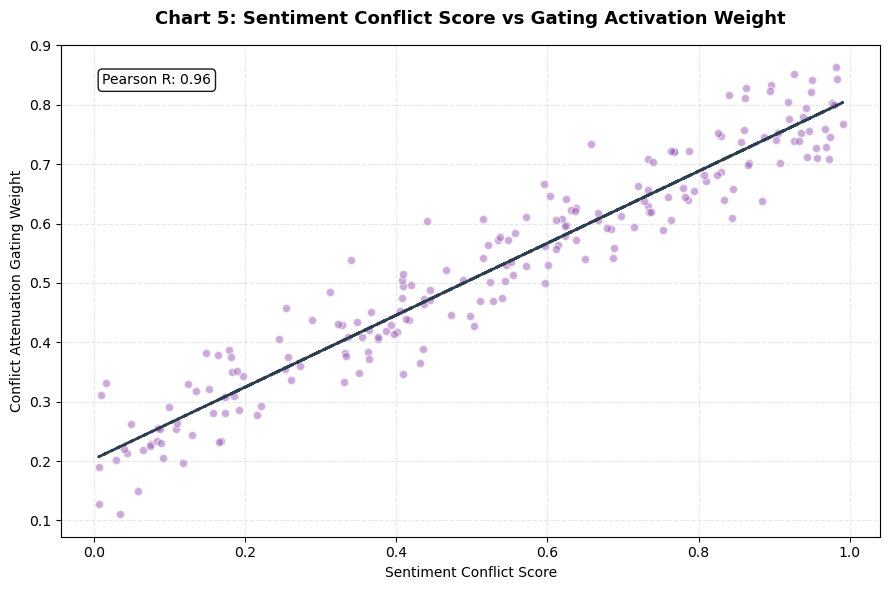

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr

np.random.seed(4)
conflict_score = np.random.uniform(0, 1, 200)
gating_weight = 0.2 + 0.6 * conflict_score + np.random.normal(0, 0.05, 200)

r_value, _ = pearsonr(conflict_score, gating_weight)

plt.figure(figsize=(9, 6))
plt.scatter(conflict_score, gating_weight, alpha=0.5, color='#9b59b6', edgecolors='w')
z = np.polyfit(conflict_score, gating_weight, 1)
plt.plot(conflict_score, np.poly1d(z)(conflict_score), '--', color='#2c3e50', linewidth=2)

plt.text(0.05, 0.92, f'Pearson R: {r_value:.2f}', transform=plt.gca().transAxes,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
plt.title('Chart 5: Sentiment Conflict Score vs Gating Activation Weight', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Sentiment Conflict Score')
plt.ylabel('Conflict Attenuation Gating Weight')
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('Data/charts_img/rq3_scatter_gating.png', dpi=300, bbox_inches='tight')
plt.show()

### 4.6. [Link To RQ3] Chart 5: Chart 6: Heatmap Correlation (F1 theo mức mâu thuẫn × biến thể)

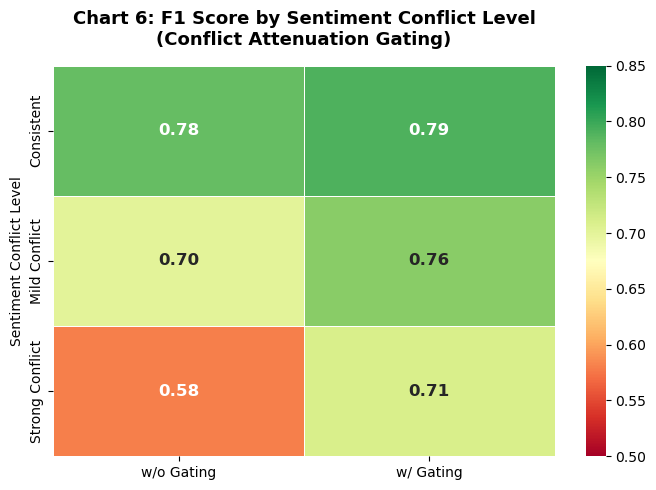

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

data_rq3 = pd.DataFrame({
    'w/o Gating': [0.78, 0.70, 0.58],
    'w/ Gating':  [0.79, 0.76, 0.71]
}, index=['Consistent', 'Mild Conflict', 'Strong Conflict'])

plt.figure(figsize=(7, 5))
sns.heatmap(data_rq3, annot=True, cmap='RdYlGn', fmt=".2f", linewidths=0.5,
            annot_kws={"size": 12, "weight": "bold"}, vmin=0.5, vmax=0.85)
plt.title('Chart 6: F1 Score by Sentiment Conflict Level\n(Conflict Attenuation Gating)', fontsize=13, fontweight='bold', pad=15)
plt.ylabel('Sentiment Conflict Level')
plt.tight_layout()
plt.savefig('Data/charts_img/rq3_heatmap_gating.png', dpi=300, bbox_inches='tight')
plt.show()

### 4.7. [Link To RQ4] Chart 7: Line Chart (F1 theo ngưỡng dung sai biên span)

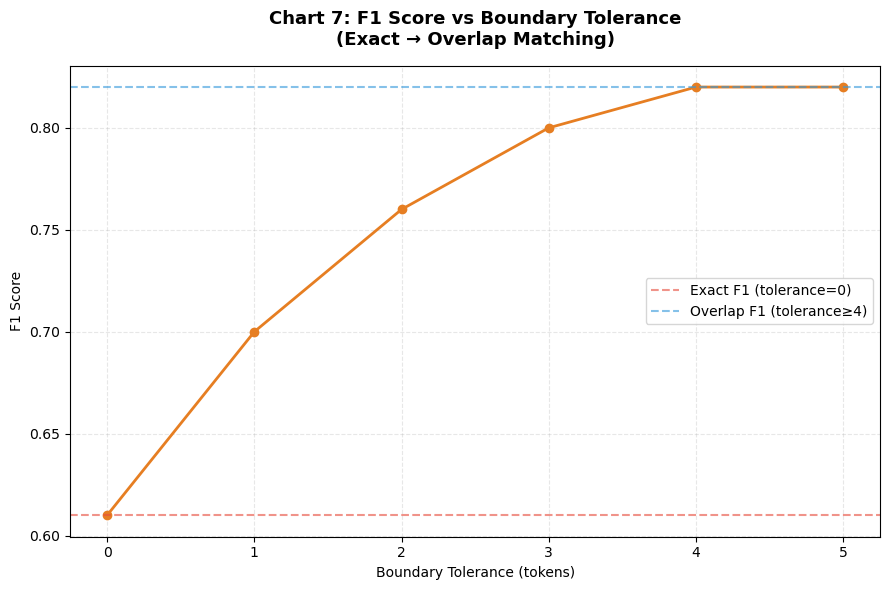

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

tolerance = [0, 1, 2, 3, 4, 5]  # số token lệch biên được chấp nhận
f1_by_tolerance = [0.61, 0.70, 0.76, 0.80, 0.82, 0.82]

plt.figure(figsize=(9, 6))
plt.plot(tolerance, f1_by_tolerance, marker='o', color='#e67e22', linewidth=2)
plt.axhline(0.61, color='#e74c3c', linestyle='--', alpha=0.6, label='Exact F1 (tolerance=0)')
plt.axhline(0.82, color='#3498db', linestyle='--', alpha=0.6, label='Overlap F1 (tolerance≥4)')

plt.title('Chart 7: F1 Score vs Boundary Tolerance\n(Exact → Overlap Matching)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Boundary Tolerance (tokens)')
plt.ylabel('F1 Score')
plt.legend()
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('Data/charts_img/rq4_linechart_tolerance.png', dpi=300, bbox_inches='tight')
plt.show()

### 4.8. [Link To RQ4] Chart 8: Bar Chart (phân bổ nguồn gốc lỗi)

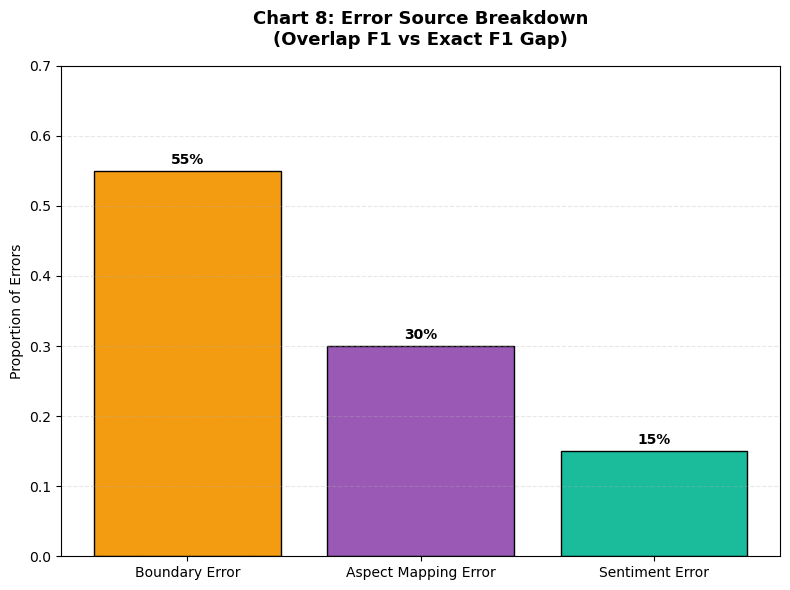

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

error_breakdown = pd.DataFrame({
    'Error_Type': ['Boundary Error', 'Aspect Mapping Error', 'Sentiment Error'],
    'Proportion': [0.55, 0.30, 0.15]
})

plt.figure(figsize=(8, 6))
bars = plt.bar(error_breakdown['Error_Type'], error_breakdown['Proportion'],
                color=['#f39c12', '#9b59b6', '#1abc9c'], edgecolor='black')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{bar.get_height():.0%}', ha='center', fontweight='bold')

plt.title('Chart 8: Error Source Breakdown\n(Overlap F1 vs Exact F1 Gap)', fontsize=13, fontweight='bold', pad=15)
plt.ylabel('Proportion of Errors')
plt.ylim(0, 0.7)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('Data/charts_img/rq4_barchart_errors.png', dpi=300, bbox_inches='tight')
plt.show()

### 4.9. [Link To RQ5] Chart 9: Boxplot (phân phối F1 qua nhiều lần chạy)

C:\Users\Windows\AppData\Local\Temp\ipykernel_14124\2484929200.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data_rq5, x='Split', y='F1', palette=['#2ecc71', '#e67e22'], width=0.4)


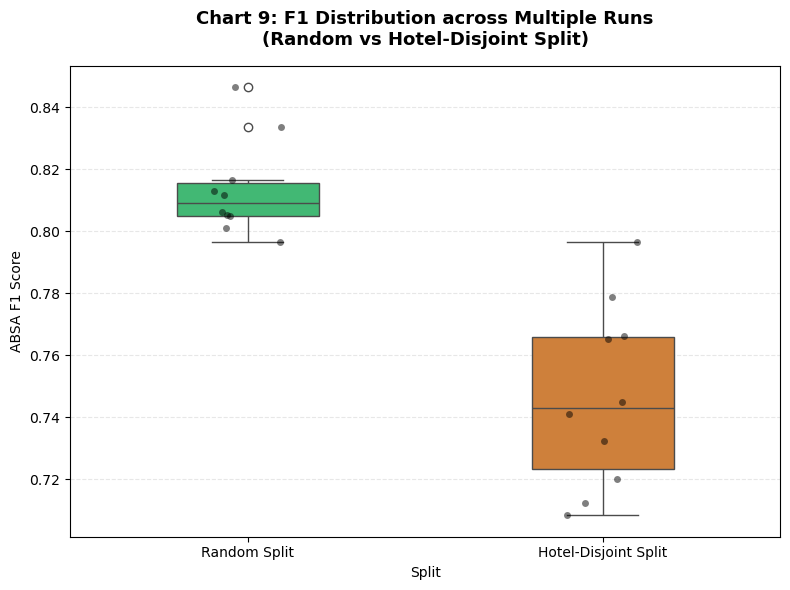

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

np.random.seed(5)
data_rq5 = pd.DataFrame({
    'F1': np.concatenate([np.random.normal(0.81, 0.015, 10), np.random.normal(0.75, 0.025, 10)]),
    'Split': ['Random Split']*10 + ['Hotel-Disjoint Split']*10
})

plt.figure(figsize=(8, 6))
sns.boxplot(data=data_rq5, x='Split', y='F1', palette=['#2ecc71', '#e67e22'], width=0.4)
sns.stripplot(data=data_rq5, x='Split', y='F1', color='black', alpha=0.5, size=5, jitter=True)

plt.title('Chart 9: F1 Distribution across Multiple Runs\n(Random vs Hotel-Disjoint Split)', fontsize=13, fontweight='bold', pad=15)
plt.ylabel('ABSA F1 Score')
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('Data/charts_img/rq5_boxplot_split.png', dpi=300, bbox_inches='tight')
plt.show()

### 4.10. [Link To RQ5] Chart 10: Stacked Bar Chart (thành phần lỗi theo chiến lược split)

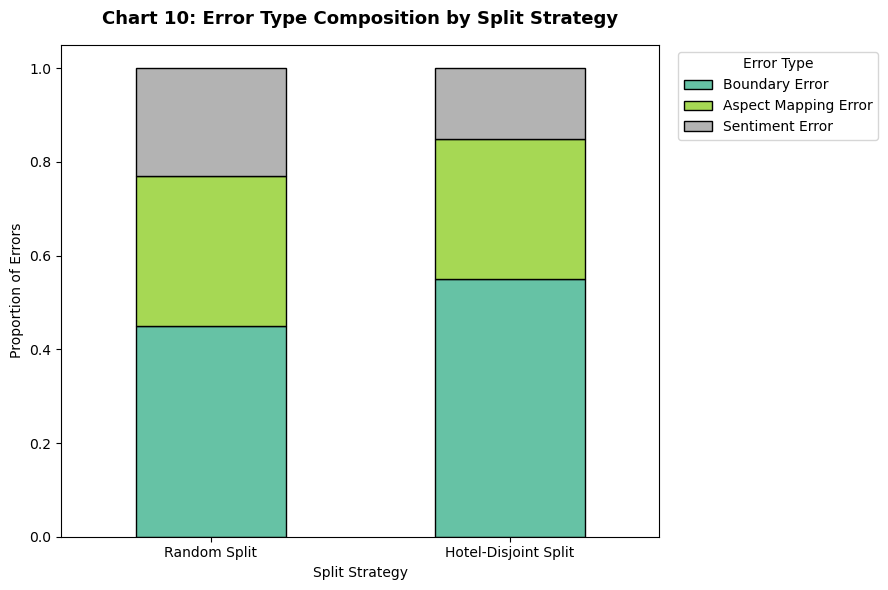

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

data_rq5_stack = pd.DataFrame({
    'Split': ['Random Split', 'Hotel-Disjoint Split'],
    'Boundary Error': [0.45, 0.55],
    'Aspect Mapping Error': [0.32, 0.30],
    'Sentiment Error': [0.23, 0.15]
}).set_index('Split')

data_rq5_stack.plot(kind='bar', stacked=True, figsize=(9, 6), colormap='Set2', edgecolor='black')
plt.title('Chart 10: Error Type Composition by Split Strategy', fontsize=13, fontweight='bold', pad=15)
plt.ylabel('Proportion of Errors')
plt.xlabel('Split Strategy')
plt.xticks(rotation=0)
plt.legend(title='Error Type', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('Data/charts_img/rq5_stackedbar_errors.png', dpi=300, bbox_inches='tight')
plt.show()